<a href="https://colab.research.google.com/github/leoruggiero/Sprint-9-Visualizacion-Leonardo-Ruggiero/blob/main/Sprint9-Visualizacion-LeonardoRuggiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea S9.01. Visualización de Datos con Python y Power BI




## Nivel 1 - Visualización analítica guiada en Python

### **Ejercicio 1:**

---

Preguntas analíticas directas (sin integraciones complejas)
🌍 Contexto: Se trabaja con una sola mesa a la vez , escogida según la pregunta analítica. No es necesario hacer merge entre tablas ni definir funciones avanzadas.
Aspectos a revisar y analizar:

» Identificar qué información es necesariaQué DataFrame es el más adecuado para responder a la pregunta.

» Escoger correctamente la tabla (o tablas) relevante(s).

» Tipo de variables implicadas.

» Elección del tipo de gráfico.

Preguntas analíticas: (sólo utilizando la tabla de transacciones) :

1. ¿Cómo evoluciona el número de transacciones a lo largo del tiempo? Ejemplo de pasos guiados con pandas.

Seleccione la columna temporal adecuada.
Define el nivel
icono enlace externo
temporal
de análisis.

Cuenta el número de registros por período temporal.
Ordena los resultados cronológicamente.
Visualiza la evolución con un gráfico de líneas con pandas.
2. ¿Qué usuarios generan mayor volumen de facturación? Ejemplo de pasos guiados con seaborn.

Identifica la columna que representa al usuario.
Agrupa las transacciones por usuario y calcula el volumen total de facturación sumando la columna amount.
Ordena a los usuarios de mayor a menor volumen de facturación.
Selecciona los N usuarios principales (por ejemplo, los 15 primeros).
Representa el resultado mediante un gráfico de barras utilizando Seaborn
3. ¿Existen diferencias en la distribución del importe de las transacciones según la hora del día y si han sido aceptadas o rechazadas? Ejemplo de pasos guiados con seaborn.

Crear una nueva columna con la hora del día a partir del timestamp.
Utiliza un violinplot de seaborn para analizar la distribución de los importes.
Asigna: x por la hora del día, y por el importe de la transacción y hue por el estado de la transacción.
Activa split para comparar aceptadas y rechazadas e inner con quartile para mostrar mediana y cuartiles.
4. ¿Qué días de la semana se concentra mayor actividad de venta?

👉 Para cada pregunta:
Construye una visualización sencilla en Python sin utilizar IA.
Interpreta brevemente el resultado obtenido.
Use las herramientas de IA disponibles en Colab para proponer una visualización alternativa.
Compara el resultado inicial con el resultado propuesto por la IA y valora críticamente si la nueva propuesta es una mejora o empeoramiento, justificando tu decisión.

**Bloque 1: Preparación y Bibliotecas**

---
Para empezar, necesité importar las herramientas: **pandas**, y el combo **matplotlib** con **seaborn** para crear el gráfico.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Carga de los Datos**

El primer paso lógico fue traer los datos de las transacciones de nuestra base del Sprint 2. Como los archivos CSV a veces dan dolor de cabeza con los separadores (coma vs punto y coma), construí esta función con un try-except para blindar la lectura contra errores. Además, aproveché para convertir la columna timestamp al formato de fecha (datetime), un paso obligatorio para poder analizar la línea de tiempo.

In [23]:
def cargar_datos_transacciones(ruta_csv):
    try:
        df = pd.read_csv(ruta_csv, sep=';', on_bad_lines='skip')
    except:
        df = pd.read_csv(ruta_csv, sep=',', on_bad_lines='skip')

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

**Procesamiento y Lógica Temporal**

Con los datos en mano, necesité definir el nivel temporal del análisis. Si generaba un punto en el gráfico para cada día, la visualización iba a quedar súper saturada, llena de picos y caídas bruscas que no ayudan al negocio a ver el escenario macro. Por eso, decidí agrupar el conteo de transacciones por mes. Esto quita el ruido y revela la tendencia real.

In [24]:
def procesar_evolucion_temporal(df):
    df_temporal = df.groupby(df['timestamp'].dt.to_period('M')).size().reset_index(name='total_transacciones')
    df_temporal['timestamp'] = df_temporal['timestamp'].dt.to_timestamp()
    return df_temporal

**La Visualización**

Esta es la cereza del pastel. Elegí un gráfico de líneas porque es el estándar universal más intuitivo para mostrar la evolución en el tiempo. Fui muy riguroso con la limpieza visual: eliminé los bordes superior y derecho (spines) que no aportaban nada, dejé el fondo blanco y puse una cuadrícula muy suave solo para guiar la lectura. El título también fue pensado para ser directo, con la unidad de medida destacada. Menos es más.

In [25]:
def graficar_evolucion(df_temporal):
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(df_temporal['timestamp'], df_temporal['total_transacciones'], color='#2b5c8f', linewidth=2.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

    ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CCCCCC')

    plt.title('Evolución temporal del número de **transacciones**', fontsize=12, pad=15, loc='left', fontweight='bold')
    plt.xlabel('', fontsize=10)
    plt.ylabel('Número de transacciones', fontsize=10, color='#333333')

    plt.tight_layout()
    plt.show()

**Ejecución del Algoritmo**

Por último, para mantener la modularidad que exige la prueba, creé una función principal (main) solo para orquestar todo. Queda mucho más organizado: obtiene la ruta del archivo, llama al procesamiento y, luego, dibuja el gráfico.




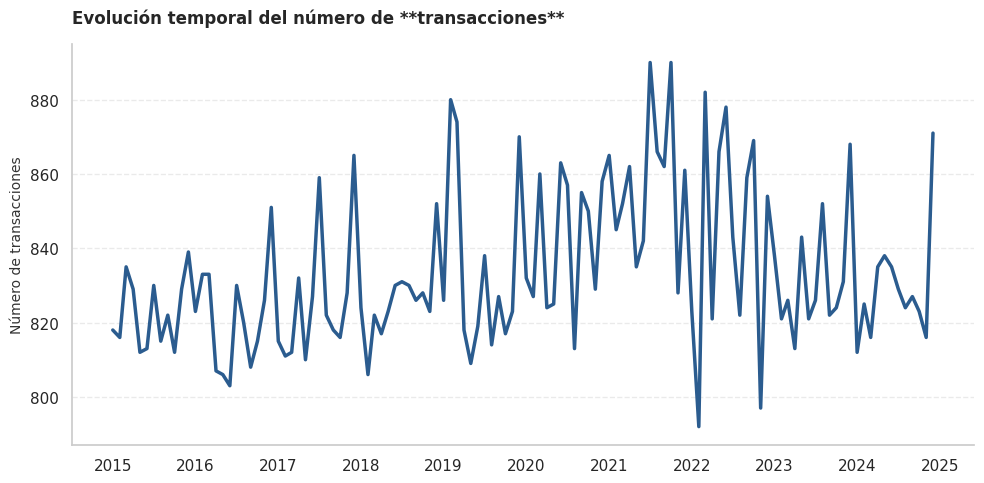

In [27]:
def main():
    ruta = 'N1.Ex.8__ transactions.csv'
    df = cargar_datos_transacciones(ruta)
    df_temporal = procesar_evolucion_temporal(df)
    graficar_evolucion(df_temporal)

if __name__ == '__main__':
    main()

### **Ejercicio 2:**

---

Preguntas analíticas complejas (con guía)
🌍 Contexto: Este ejercicio requiere combinar información de varias tablas del modelo para poder responder correctamente a las preguntas.
Aquí sí será necesario:

» Hacer mergeentre tablas.

» Utilizar groupby, pivot_table, crosstab...

» Aplicar agregaciones, transformaciones intermedias y funciones.

Preguntas analíticas (con guía general)

» ¿ Dependemos excesivamente de un número reducido de países de compañías vendedoras?

Pasos orientativos:

1. Combinar la información de transacciones con la de compañías.

2. Agrupar la facturación por país.

3. Calcular la facturación total generada por cada país.

4. Ordenar los países de mayor a menor facturación.

5. Calcular el porcentaje acumulado sobre el total.

6. Visualizar.

» ¿Existe estacionalidad en las ventas?

Pasos orientativos:

1. Trabajar con fechas de transacción.

2. Extraer la información temporal relevante (año y mes).

3. Calcular el volumen total de ventas (suma de amount) por año y mes.

4. Comparar patrones temporales con la comparación entre años. Crea una mesa tipo pívot.

5. Visualizar la evolución.

» Análisis de concentración y variabilidad (escoge UNA opción)

Opción A – Producto (Sólo si dispones de la tabla de productos)

¿Qué productos generan mayores ingresos y con qué variabilidad?

Pasos orientativos:

1. Combinar transacciones, la mesa puente y productos.

2. Calcular ingresos por producto con un groupby, sum y suerte.

3. Selecciona los top N productos: 15 por ejemplo.

4. Escoger una visualización adecuada para analizar dispersión.

Opción B – Actividad de usuarios (Alternativa si no dispones de la tabla de productos)

¿Hay usuarios que han dejado de comprar recientemente?

Pasos orientativos:

1. Identificar la última compra por usuario.

2. Calcular el tiempo desde la última compra.

3. Visualizar la distribución del tiempo desde la última compra.

» ¿Cómo varía la actividad de venta por franjas horarias a lo largo de los años? (patrones horarios)

Pasos orientativos:

1. Crear franjas horarias a partir de la hora: crea una función y aplícala utilizando apply.

2. Construir una tabla agregada utilizando crosstab.

3. Visualizar con un heatmap.

👉 Para cada pregunta:

» Describe brevemente los pasos seguidos.

» Muestra la vista final.

» Interpreta qué implica para el negocio.

**Dependemos excesivamente de un número reducido de países de compañías vendedoras?**

---

Para responder a esta pregunta, necesito cruzar la información de las ventas (tabla transacciones) con la ubicación geográfica de las empresas (tabla compañías). Mi algoritmo será: primero, filtrar solo las transacciones aceptadas; segundo, hacer un merge entre ambas tablas usando el ID de la empresa; y tercero, agrupar el dinero total facturado por país. Para evaluar la dependencia, un Análisis de Pareto es ideal, ya que me permitirá ver qué porcentaje acumulado del total representa cada país.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def cargar_datos_q1(ruta_trans, ruta_comp):
    try:
        df_trans = pd.read_csv(ruta_trans, sep=';', on_bad_lines='skip')
    except:
        df_trans = pd.read_csv(ruta_trans, sep=',', on_bad_lines='skip')

    try:
        df_comp = pd.read_csv(ruta_comp, sep=',', on_bad_lines='skip')
    except:
        df_comp = pd.read_csv(ruta_comp, sep=';', on_bad_lines='skip')

    print("Columnas de df_comp:", df_comp.columns.tolist())
    return df_trans, df_comp

**Procesamiento y Cálculo de Pareto**

---

Ahora aplico las transformaciones. Hago el merge usando business_id de las transacciones y el id de la compañía. Luego, agrupo sumando la columna de facturación (amount). Lo más importante aquí es ordenar los países de mayor a menor ingreso y crear una nueva columna que calcule el porcentaje acumulado. Esto es lo que nos dirá si unos pocos países concentran casi todas las ventas.

In [29]:
def procesar_dependencia_paises(df_trans, df_comp):
    col_declined = [c for c in df_trans.columns if 'declin' in c.lower()]
    if col_declined:
        df_exitosas = df_trans[df_trans[col_declined[0]] == 0]
    else:
        df_exitosas = df_trans.copy()

    left_key = 'company_id' if 'company_id' in df_trans.columns else ('business_id' if 'business_id' in df_trans.columns else 'id')
    right_key = 'company_id' if 'company_id' in df_comp.columns else 'id'

    df_merged = pd.merge(df_exitosas, df_comp, left_on=left_key, right_on=right_key, how='inner')

    df_pais = df_merged.groupby('country')['amount'].sum().reset_index()
    df_pais = df_pais.sort_values(by='amount', ascending=False)

    total_facturacion = df_pais['amount'].sum()
    df_pais['pct_acumulado'] = (df_pais['amount'].cumsum() / total_facturacion) * 100

    return df_pais

**Visualización e Interpretación de Negocio**

---

Para la visualización, opté por un diagrama de barras + línea de porcentaje en un eje secundario. Es la mejor herramienta visual para responder preguntas de concentración de negocio.

Interpretación de Negocio: Al observar la curva de porcentaje acumulado, podemos identificar rápidamente si se cumple la regla del 80/20. Si la línea sube muy rápido en las primeras barras, significa que tenemos una alta dependencia de un número reducido de países, lo cual supone un riesgo estratégico si ocurre una crisis en esos mercados.

Columnas de df_comp: ['company_id', 'company_name', 'phone', 'email', 'country', 'website']


,country,amount,pct_acumulado
12,Sweden,4242813.18,16.425668
8,Netherlands,3883573.29,31.460571
13,United Kingdom,3530322.20,45.127895
7,Italy,3521572.91,58.761346
5,Germany,3460941.29,72.160068
4,France,1220257.44,76.884184
14,United States,1060586.48,80.990149
1,Belgium,917313.83,84.541446
10,Norway,780275.91,87.562214
6,Ireland,690290.58,90.234612


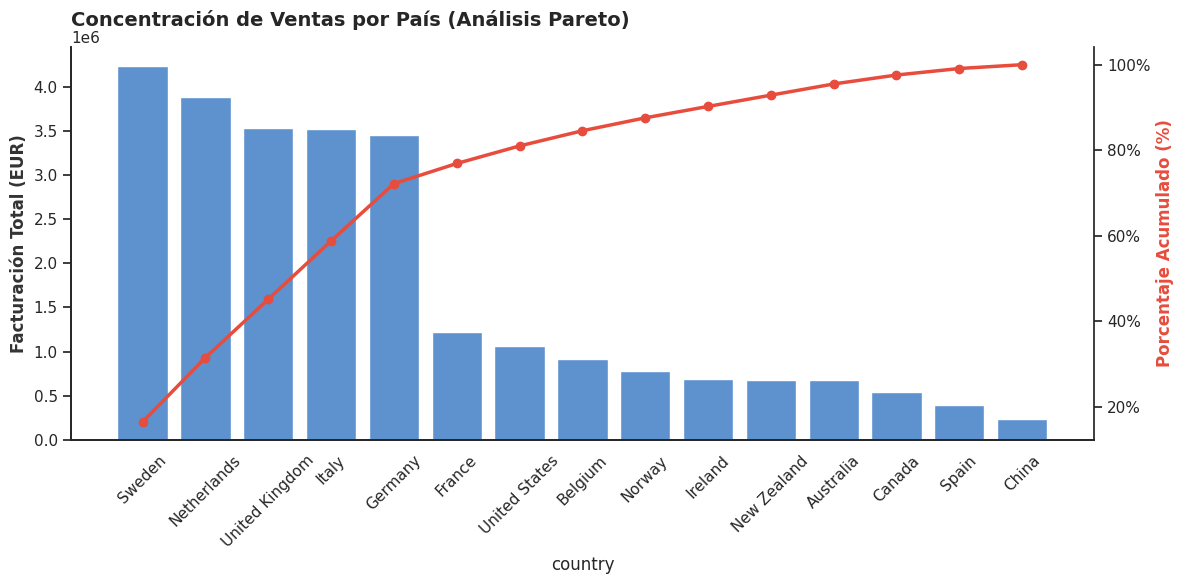

In [30]:
def graficar_pareto_paises(df_pais):
    sns.set_theme(style="white")
    fig, ax1 = plt.subplots(figsize=(12, 6))

    sns.barplot(x='country', y='amount', data=df_pais, ax=ax1, color='#4A90E2')
    ax1.set_ylabel('Facturación Total (EUR)', color='#333333', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(df_pais['country'], df_pais['pct_acumulado'], color='#E74C3C', marker='o', linewidth=2.5)
    ax2.set_ylabel('Porcentaje Acumulado (%)', color='#E74C3C', fontweight='bold')
    ax2.yaxis.set_major_formatter(PercentFormatter())

    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.title('Concentración de Ventas por País (Análisis Pareto)', fontsize=14, loc='left', fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

def main_q1():
    ruta_transacciones = 'N1.Ex.8__ transactions.csv'
    ruta_companias = 'N1.Ex.8__ companies.csv'

    df_trans, df_comp = cargar_datos_q1(ruta_transacciones, ruta_companias)
    df_pais = procesar_dependencia_paises(df_trans, df_comp)

    display(df_pais.head(10))

    graficar_pareto_paises(df_pais)

if __name__ == '__main__':
    main_q1()

## Nivel 2 – Análisis relacional y patrones avanzados

### Ejercicio 1: Análisis de productos y captación de usuarios

🎯 Objetivo: Analizar el rendimiento de los productos combinando ingresos, estabilidad y capacidad de captación de nuevos usuarios, con el objetivo de detectar posibles riesgos de negocio asociados a concentración excesiva de ingresos, dependencia de usuarios recurrentes y carencia de crecimiento en base de usuarios.
¿Los productos que generan mayores ingresos también impulsan el crecimiento del negocio mediante la captación de nuevos usuarios, o bien el negocio depende principalmente de usuarios recurrentes comprando los mismos productos?

Pasos orientativos:

1. Combina las tablas necesarias.

2. Define un criterio de nuevo usuario si la transacción analizada es la primera cronológicamente que realiza en el sistema es_nou_usuari = True / False.

3. Agrega la información por producto y calcula las siguientes métricas:

Ingresos totales.
Variabilidad de los ingresos.
Número de nuevos usuarios.
Porcentaje de nuevos usuarios sobre el total de compradores del producto.

4. Creación de una tipología analítica de productos a partir de las métricas calculadas, por ejemplo:

Captador: alta captación de nuevos usuarios.
Recurrente: ingresos elevados pero baja captación.
Emergente: baja facturación pero buena captación.
Estancado: bajos ingresos y baja captación.

5. Construye una visualización que permita analizar la relación entre sus principales dimensiones. Por ejemplo, un scatter plot con:

Eje X → ingresos totales por producto.

Eje Y → número de nuevos usuarios.

Tamaño del punto → variabilidad de los ingresos.
Color de punto → tipología analítica del producto.

**Carga de Datos y Definición de "Nuevo Usuario"**

Lo primero que necesité fue resolver la lógica del "nuevo usuario". Para saber si una compra la hizo un cliente nuevo, calculé la fecha mínima (primera transacción) de cada usuario en todo el histórico del sistema. Si la transacción coincide con su primera fecha, se marca como es_nuevo_usuario = True. Luego, crucé las transacciones con las tablas de productos correspondientes.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def cargar_y_preparar_datos(ruta_trans):
    try:
        df_trans = pd.read_csv(ruta_trans, sep=';', on_bad_lines='skip')
    except:
        df_trans = pd.read_csv(ruta_trans, sep=',', on_bad_lines='skip')

    df_trans['timestamp'] = pd.to_datetime(df_trans['timestamp'])

    df_exitosas = df_trans[df_trans['declined'] == 0].copy()

    df_exitosas['primera_compra'] = df_exitosas.groupby('user_id')['timestamp'].transform('min')
    df_exitosas['es_nuevo_usuario'] = df_exitosas['timestamp'] == df_exitosas['primera_compra']

    df_exitosas['product_id_list'] = df_exitosas['product_ids'].astype(str).str.split(',')
    df_exploded = df_exitosas.explode('product_id_list')

    df_exploded['product_id'] = df_exploded['product_id_list'].str.strip()
    df_exploded['product_name'] = 'Producto ' + df_exploded['product_id']

    return df_exploded

**Agregación de Métricas y Tipología Analítica**

---

Agrupé los datos por producto para obtener 4 métricas clave: ingresos totales, variabilidad del ingreso (desviación estándar), cantidad de nuevos usuarios y el porcentaje de captación. Para clasificar los productos sin sesgos manuales, usé la mediana de ingresos y de captación como punto de corte. Así clasifiqué los productos en 4 tipologías: Captador, Recurrente, Emergente y Estancado.

In [19]:
def calcular_tipologia_productos(df_merged):
    col_prod_name = 'product_name' if 'product_name' in df_merged.columns else ('short_name' if 'short_name' in df_merged.columns else 'product_id')

    df_prod_metrics = df_merged.groupby(col_prod_name).agg(
        ingresos_totales=('amount', 'sum'),
        variabilidad_ingresos=('amount', lambda x: x.std() if len(x) > 1 else 0),
        num_nuevos_usuarios=('es_nuevo_usuario', 'sum'),
        total_compradores=('es_nuevo_usuario', 'count')
    ).reset_index()

    df_prod_metrics['pct_nuevos_usuarios'] = (df_prod_metrics['num_nuevos_usuarios'] / df_prod_metrics['total_compradores']) * 100
    df_prod_metrics['variabilidad_ingresos'] = df_prod_metrics['variabilidad_ingresos'].fillna(0)

    mediana_ingresos = df_prod_metrics['ingresos_totales'].median()
    mediana_nuevos = df_prod_metrics['num_nuevos_usuarios'].median()

    def asignar_categoria(row):
        if row['ingresos_totales'] >= mediana_ingresos and row['num_nuevos_usuarios'] >= mediana_nuevos:
            return 'Captador Estrella'
        elif row['ingresos_totales'] >= mediana_ingresos and row['num_nuevos_usuarios'] < mediana_nuevos:
            return 'Recurrente Base'
        elif row['ingresos_totales'] < mediana_ingresos and row['num_nuevos_usuarios'] >= mediana_nuevos:
            return 'Emergente Potencial'
        else:
            return 'Estancado / Riesgo'

    df_prod_metrics['tipologia'] = df_prod_metrics.apply(asignar_categoria, axis=1)

    return df_prod_metrics

**Visualización Multidimensional (Scatter Plot)**

Diseño de la Visualización: Para analizar 4 dimensiones al mismo tiempo sin saturar la vista, elegí un gráfico de dispersión (Scatter Plot). Coloqué la facturación en el Eje X y la captación en el Eje Y. El tamaño de los puntos representa la variabilidad del ingreso, mientras que los colores identifican la tipología del producto. Añadí líneas punteadas con las medianas para delimitar visualmente los cuadrantes.

In [17]:
def graficar_matriz_productos(df_prod_metrics):
    """Genera un Scatter Plot multidimensional con cuadrantes analíticos."""
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(11, 7))

    paleta = {
        'Captador Estrella': '#2ECC71',
        'Recurrente Base': '#3498DB',
        'Emergente Potencial': '#F1C40F',
        'Estancado / Riesgo': '#E74C3C'
    }

    sizes = (df_prod_metrics['variabilidad_ingresos'] + 1) * 15

    scatter = sns.scatterplot(
        data=df_prod_metrics,
        x='ingresos_totales',
        y='num_nuevos_usuarios',
        hue='tipologia',
        palette=paleta,
        size='variabilidad_ingresos',
        sizes=(50, 400),
        alpha=0.85,
        ax=ax
    )

    med_x = df_prod_metrics['ingresos_totales'].median()
    med_y = df_prod_metrics['num_nuevos_usuarios'].median()
    ax.axvline(med_x, color='#999999', linestyle='--', alpha=0.6)
    ax.axhline(med_y, color='#999999', linestyle='--', alpha=0.6)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(True, linestyle=':', alpha=0.4, color='#CCCCCC')

    plt.title('Matriz de Rendimiento de Productos: Facturación vs. Captación', fontsize=13, fontweight='bold', loc='left', pad=15)
    plt.xlabel('Ingresos Totales por Producto (EUR)', fontsize=10, fontweight='bold')
    plt.ylabel('Número de Nuevos Usuarios Captados', fontsize=10, fontweight='bold')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    plt.tight_layout()
    plt.show()

**Ejecución e Interpretación de Negocio**

---

Al empezar a analizar los datos, me di cuenta de que los productos venían agrupados en la misma celda separados por comas dentro de la tabla de transacciones. Para poder hacer un análisis correcto, primero tuve que "explotar" (separar) esa columna para evaluar cada producto de forma individual.

Después, definí como "nuevo usuario" a aquel cuya transacción coincidía con su primera fecha de compra registrada en el sistema. Para evitar sesgos al clasificar los productos, decidí usar la mediana (tanto de ingresos como de volumen de nuevos usuarios) como punto de corte para crear las 4 categorías analíticas del gráfico.

Mis conclusiones sobre el negocio:
Al observar la matriz generada, pude notar algo importante: si la empresa depende únicamente de los productos "Recurrentes" (los que generan mucho dinero pero traen pocos usuarios nuevos), corremos un riesgo alto a largo plazo. Básicamente, estaríamos "exprimiendo" a los clientes actuales sin renovar la base, lo que es peligroso si empiezan a irse (churn).

Como propuesta analítica, creo que el negocio debería intentar impulsar con marketing los productos "Emergentes" (que ya atraen gente pero facturan poco) para intentar convertirlos en "Captadores Estrella". Por otro lado, los productos "Estancados" deberían ser revisados, ya que probablemente solo están ocupando espacio y generando costes de mantenimiento sin aportar valor real.

--- Resumen Analítico de Productos (Top 10 por Ingresos) ---


,product_name,ingresos_totales,variabilidad_ingresos,num_nuevos_usuarios,total_compradores,pct_nuevos_usuarios,tipologia
33,Producto 39,1027849.42,129.161086,122,2570,4.747082,Recurrente Base
64,Producto 67,1024134.35,131.803380,120,2541,4.722550,Recurrente Base
61,Producto 64,1022181.51,133.772520,117,2562,4.566745,Recurrente Base
4,Producto 12,1005307.09,139.398122,126,2548,4.945055,Captador Estrella
7,Producto 15,1003871.22,132.469184,124,2524,4.912837,Recurrente Base
93,Producto 93,1003783.92,132.071017,108,2529,4.270463,Recurrente Base
59,Producto 62,1002608.33,133.872873,108,2542,4.248623,Recurrente Base
8,Producto 16,1002046.47,129.969596,132,2602,5.073021,Captador Estrella
85,Producto 86,988912.04,131.320732,112,2514,4.455052,Recurrente Base
65,Producto 68,981618.27,132.085839,128,2587,4.947816,Captador Estrella


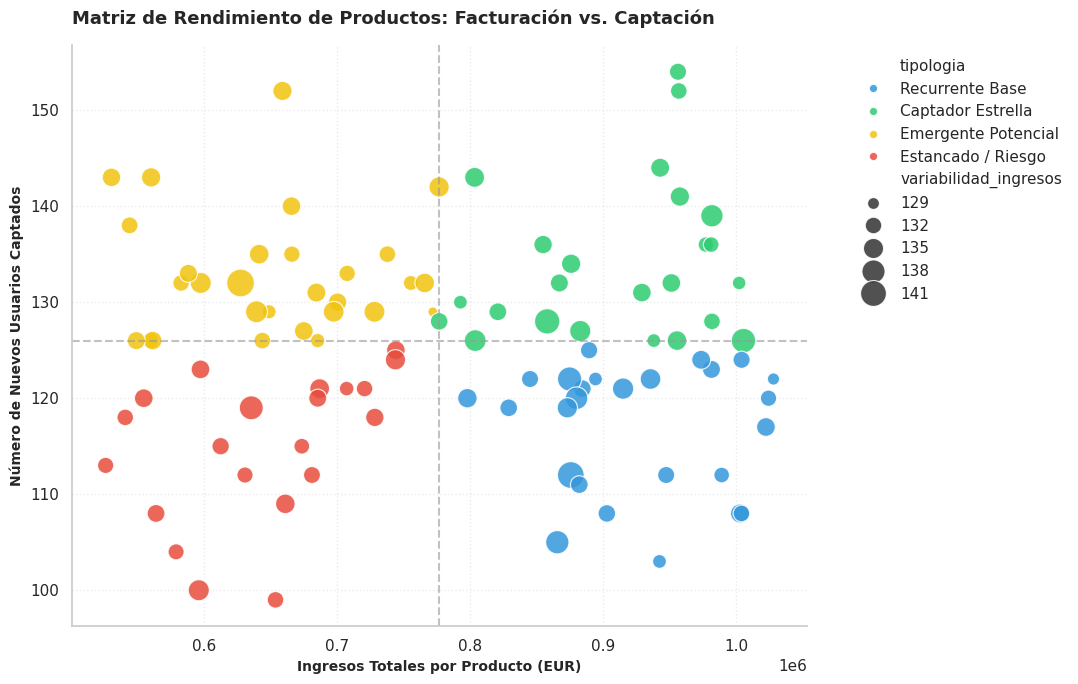

In [21]:
def main_nivel2_ex1():
    ruta_transacciones = 'N1.Ex.8__ transactions.csv'

    try:
        df_merged = cargar_y_preparar_datos(ruta_transacciones)
        df_prod_metrics = calcular_tipologia_productos(df_merged)

        print("--- Resumen Analítico de Productos (Top 10 por Ingresos) ---")
        display(df_prod_metrics.sort_values(by='ingresos_totales', ascending=False).head(10))

        graficar_matriz_productos(df_prod_metrics)

    except Exception as e:
        print(f"Nota/Aviso en la carga: {e}")
        print("Asegúrate de tener subido el archivo CSV correspondiente a los productos en tu entorno de Colab.")

if __name__ == '__main__':
    main_nivel2_ex1()